Conditions
* 10: 2 hour GC incubation, 6uL M.CviPI in 200 uL Hia5 buffer
* 11: 15 min. GC incubation, 6uL M.CviPI in 200 uL Hia5 buffer
* 12: nanoNOMe incubation, 15 min. GC incubation, 50uL M.CviPI in 500 uL nanoNOMe buffer, lots of nuclei
* 13: no-accessibility control
* 14: nanoNOMe incubation, 15 min. GC incubation, 50uL M.CviPI in 500 uL nanoNOMe buffer, 500k nuclei

In [ ]:
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from scipy import stats

import config, plotting
from dimelo import parse_bam, plot_enrichment_profile, load_processed

In [4]:
reference_file = config.raw_data_dir / "chm13v2.0.fa"
ctcf_bed_file = config.processed_data_dir / "gm12878_ctcf_motif_intersect_chip.top3k.bed"
ctcf_on_target_bed_file = config.processed_data_dir / "gm12878_ctcf.on_target.bed"
bam_dir = config.processed_data_dir / "20240831_GpC_CpG_crosstalk_demuxed"
barcodes = [10, 11, 12, 13]

# NOTE: Match window sizes set in third_party_data.ipynb
window_size = 1500
ctcf_on_target_window_size = 200
motifs = ["A,0", "GCH,1", "GCH,1,h", "WCG,1", "WCG,1,h"]
mod_prob_thresh = 0.75
smoothing = 25
n_cores = 10

y_lim = (-0.01, 0.62)

# Parsing

In [3]:
for barcode in barcodes:
    bam_file = bam_dir / f"barcode{barcode}.bam"
    # TODO: This should be renamed so that there is no risk of overlapping with demuxed files from another dataset; maybe make a subdirectory?
    output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}.thresh75"
    parse_bam.pileup(
        input_file=bam_file,
        output_name=f"pileup.{output_id}",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=ctcf_bed_file,
        motifs=motifs,
        thresh=mod_prob_thresh,
        window_size=window_size,
        cores=n_cores,
        override_checks=True
    )
    parse_bam.extract(
        input_file=bam_file,
        output_name=f"extract.{bam_file.stem}.gm12878_ctcf.on_target",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=ctcf_on_target_bed_file,
        motifs=motifs,
        thresh=None, # No thresholding at extract time
        window_size=None,
        cores=n_cores,
        override_checks=True,
    )

Allocating requested 10 cores.
Modification threshold of 0.75 will be treated as coming from range 0-1.


          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in barcode10.bam   0% | 00:00<?

          |    0%

Allocating requested 10 cores.
No valid base modification threshold provided. Raw probs will be saved.


...

          | Transferring 2487 from reads.WCG,1.txt into reads.combined_basemods.h5, new size 10817   0% | 00:0…

          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in barcode13.bam   0% | 00:00<?

          |    0%

          | Transferring 2487 from reads.WCG,1,h.txt into reads.combined_basemods.h5, new size 13304   0% | 00…

# Figures

## Fig. 3

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

...

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

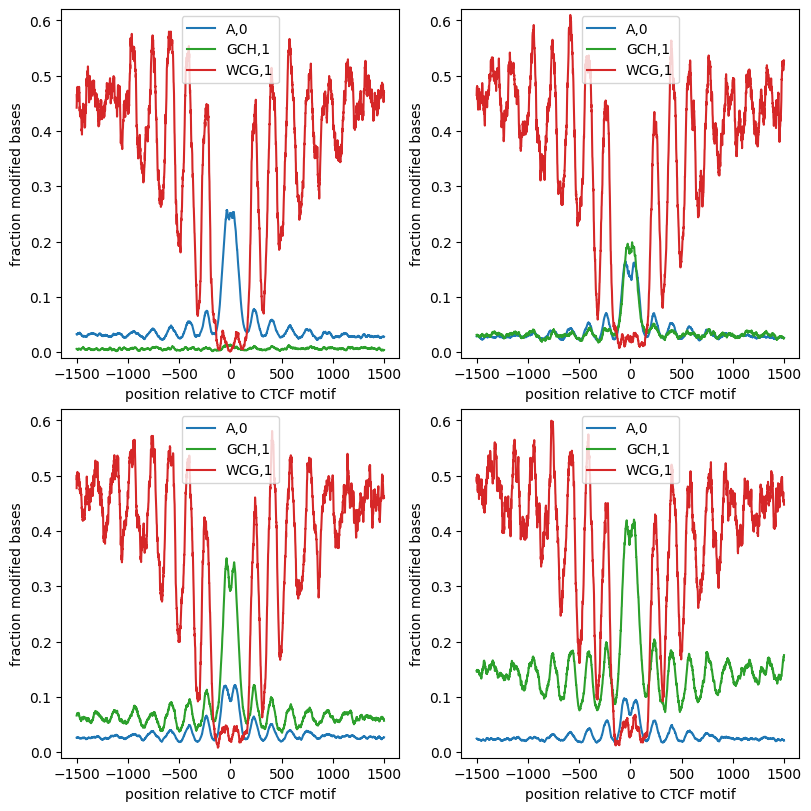

In [7]:
_, axs = plt.subplots(2, 2, figsize=(8, 8), layout="constrained")
for barcode, ax in zip([13, 11, 10, 12], np.ravel(axs)):
    bam_file = bam_dir / f"barcode{barcode}.bam"
    # TODO: This should be renamed so that there is no risk of overlapping with demuxed files from another dataset; maybe make a subdirectory?
    output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}"
    plot_enrichment_profile.by_modification(
        config.processed_data_dir / f"pileup.{output_id}.thresh75" / "pileup.sorted.bed.gz",
        regions=ctcf_bed_file,
        motifs=["A,0","GCH,1", "WCG,1"],
        window_size=window_size,
        smooth_window=smoothing,
        palette=plotting.default_palette_map,
        ax=ax
    )
    ax.set_xlabel("position relative to CTCF motif")
    ax.set_ylim(y_lim)
    ax.legend(title="")

plt.savefig(config.figure_dir / "crosstalk.plot_enrichment_profile.svg")
plt.show()
plt.close()

# Supplemental Figures

## Supplemental Figure S5

Load read extractions as a dict of `{motif: list[mod_vector]}`, where each `mod_vector` containins reported modification probabilities for each valid base in each read for a given experimental condition.

In [ ]:
motif_mod_vectors = defaultdict(list)
for motif in motifs:
    for barcode in [13, 11, 10, 12]:
        bam_file = bam_dir / f"barcode{barcode}.bam"
        file_path = config.processed_data_dir / f"extract.{bam_file.stem}.gm12878_ctcf.on_target" / "reads.combined_basemods.h5"
        read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
            file=file_path,
            motifs=[motif],
            regions=ctcf_on_target_bed_file,
            single_strand=False,
            sort_by="shuffle",
            calculate_mod_fractions=False,
        )
        mod_vector_index = entry_labels.index("mod_vector")
        val_vector_index = entry_labels.index("val_vector")
        mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
        motif_mod_vectors[motif].append(mod_vector)

Store modification probability PMFs as a dict of `{motif: list[mod_prob_pmf]}` (same structure as `motif_mod_vectors`), where each `mod_prob_pmf` contains counts of bases with each of the 256 possible modification probability values.

In [ ]:
def mod_prob_pmf(mod_prob_vector: np.ndarray) -> np.ndarray:
    """
    Returns a vector containing the PMF corresponding to the given mod prob vector.

    Guaranteed to return a normalized 256-element array.
    """
    hist, _ = np.histogram(mod_prob_vector, bins=256, range=(0, 1))
    return(hist / np.sum(hist))

motif_mod_pmfs = {motif: [mod_prob_pmf(v) for v in mod_vecs] for motif, mod_vecs in motif_mod_vectors.items()}

256 equally spaced values between 0 and 1, with standard correction, to act as the x-axis values

In [ ]:
mod_prob_pmf_values = (np.linspace(0, 1, 257) - ((0 + 0.5) / 256))[1:]

Perform bootstrap resampling of Wasserstein distances between the modification probability distributions of the control condition and each of the other experimental conditions.

In [ ]:
bootstrap_results = defaultdict(list)
for motif in motifs:
    for i in range(4):
        # NOTE: using method "basic" because "BCa" crashed the kernel
        data = (motif_mod_vectors[motif][0], motif_mod_vectors[motif][i])
        bootstrap_result = stats.bootstrap(data, stats.wasserstein_distance, vectorized=False, rng=42, n_resamples=1000, method="basic")
        bootstrap_results[motif].append(bootstrap_result)

Build plot

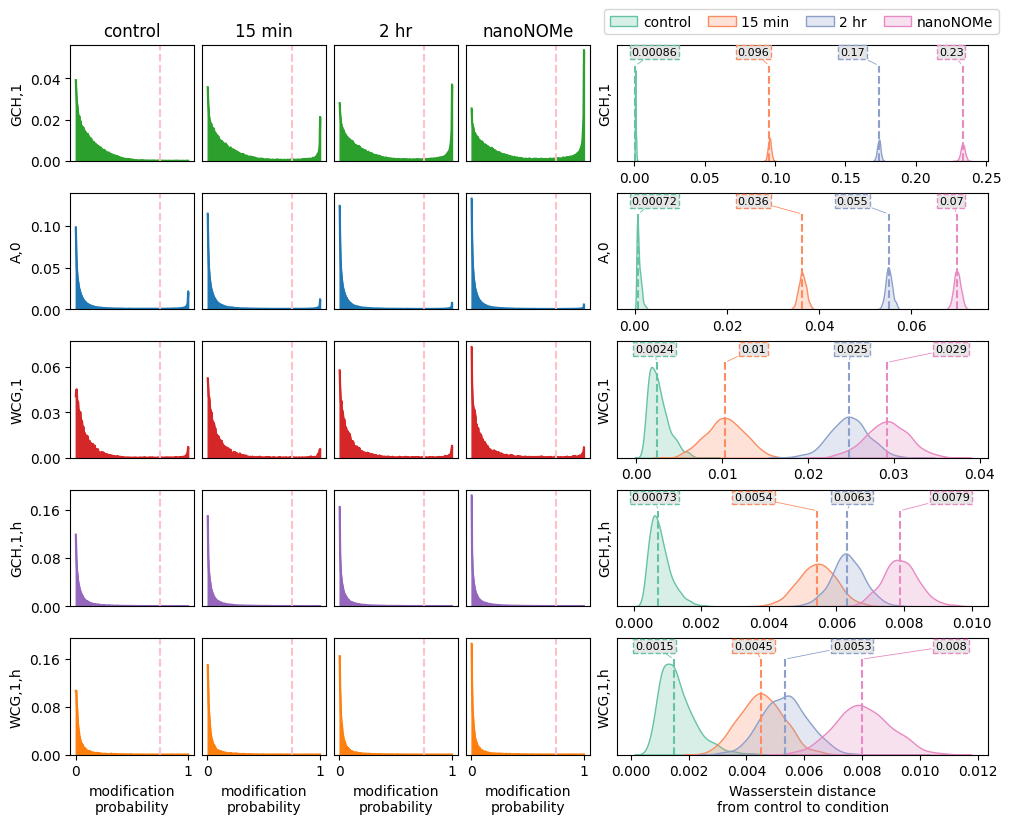

In [24]:
labels = ["control", "15 min", "2 hr", "nanoNOMe"]
experiment_pallete = sns.color_palette("Set2")
motifs = ["GCH,1", "A,0", "WCG,1", "GCH,1,h", "WCG,1,h"]


def label_strip(ax, medians, colors, strip_frac=0.16, edge_frac=0.10, fs=8):
    """
    Adds evenly-spaced value labels in a strip above the curves, each with a
    leader line to its median. Sorted so leaders never cross; expands ylim.
    """
    grey = (0.9, 0.9, 0.9)
    y0, y1 = ax.get_ylim()
    yr = y1 - y0
    ax.set_ylim(y0, y1 + strip_frac * yr + 0.06 * yr)
    xr = ax.get_xlim(); xw = xr[1] - xr[0]
    y_text = y1 + (strip_frac * 0.5 + 0.06) * yr
    slots = np.linspace(xr[0] + edge_frac * xw, xr[1] - edge_frac * xw, len(medians))
    ax.vlines(medians, 0, y1, colors=colors, linestyle="--", zorder=1)
    for slot_i, idx in enumerate(np.argsort(medians)):
        ax.annotate(f"{medians[idx]:.2}", xy=(medians[idx], y1),
                    xytext=(slots[slot_i], y_text), ha="center", va="center",
                    fontsize=fs, zorder=4,
                    bbox=dict(ec=colors[idx], fc=grey, linestyle="--", pad=1.4),
                    arrowprops=dict(arrowstyle="-", color=colors[idx], lw=0.6,
                                    shrinkA=1, shrinkB=2))


# Set up figure mosaic: 5x4 grid of distributions next to a 5x3 grid of kdes. Distributions plots will be one to each column. Each KDE plot will cover all 3 columns of that row.
mosaic = [[f"{motif}:dist:{i}" for i in range(4)] + [f"{motif}:kde"] * 3 for motif in motifs]
fig, axs_dict = plt.subplot_mosaic(mosaic, layout="constrained", figsize=(10, 8))

for motif_idx, motif in enumerate(motifs):
    # Distributions
    for i, label in enumerate(labels):
        ax = axs_dict[f"{motif}:dist:{i}"]
        sns.lineplot(x=mod_prob_pmf_values, y=motif_mod_pmfs[motif][i], ax=ax, color=plotting.default_palette_map[motif])
        ax.fill_between(mod_prob_pmf_values, motif_mod_pmfs[motif][i], color=plotting.default_palette_map[motif])
        if motif_idx == 0:
            ax.set_title(labels[i])
        if motif_idx != 4:
            ax.set_xticks([])
        else:
            ax.set_xlabel("modification\nprobability")
        # labeled y ticks only on the leftmost dist plot of each row
        if i == 0:
            ax.set_ylabel(motif)
            ax.yaxis.set_major_locator(mticker.MaxNLocator(3))
        else:
            ax.set_yticks([])
        ax.axvline(mod_prob_thresh, linestyle="--", color="pink")

    # Shared y limits across the row
    dist_axes = [axs_dict[f"{motif}:dist:{i}"] for i in range(4)]
    row_ymax = max(np.max(motif_mod_pmfs[motif][i]) for i in range(4))
    for ax in dist_axes:
        ax.set_ylim(0, row_ymax * 1.05)

    # KDEs
    ax = axs_dict[f"{motif}:kde"]
    mod_vectors = motif_mod_vectors[motif]
    wds, medians = [], []
    for i in range(4):
        # Plot bootstrap resampling KDE
        sns.kdeplot(bootstrap_results[motif][i].bootstrap_distribution, label=f"{labels[i]}", color=experiment_pallete[i], fill=True, ax=ax)
        wds.append(stats.wasserstein_distance(mod_vectors[0], mod_vectors[i]))
        medians.append(np.median(bootstrap_results[motif][i].bootstrap_distribution))
    # Plot and label bootstrap resampling medians
    label_strip(ax, medians, experiment_pallete[:4])
    ax.set_ylabel(motif)
    ax.set_xlabel("")
    ax.set_yticks([])
    if motif_idx == 4:
        ax.set_xlabel("Wasserstein distance\nfrom control to condition")

# Shared condition legend as a figure legend along the top
handles, leg_labels = axs_dict["GCH,1:kde"].get_legend_handles_labels()
fig.legend(handles, leg_labels, ncols=4, loc="upper right",
           bbox_to_anchor=(1.0, 1.02), frameon=True,
           handletextpad=0.4, columnspacing=1.2)

plt.savefig(config.figure_dir / "crosstalk_supplement.svg", bbox_inches="tight")
plt.show()
plt.close()

In [51]:
def table_row(a, b, c, col_width):
    return "".join([f"{x:<{col_width}}" for x in (a, b, c)])

col_width = 30
float_precision = 4
print(table_row("condition", "bootstrap median", "measured Wasserstein distance", col_width))
print("-" * col_width * 3)
for label, median, wd in zip(labels, medians, wds):
    print(table_row(label, f"{median:.{float_precision}f}", f"{wd:.{float_precision}f}", col_width))

condition                     bootstrap median              measured Wasserstein distance 
------------------------------------------------------------------------------------------
control                       0.0015                        0.0000                        
15 min                        0.0045                        0.0041                        
2 hr                          0.0053                        0.0052                        
nanoNOMe                      0.0080                        0.0079                        


## Supplemental Figure S6

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

...

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

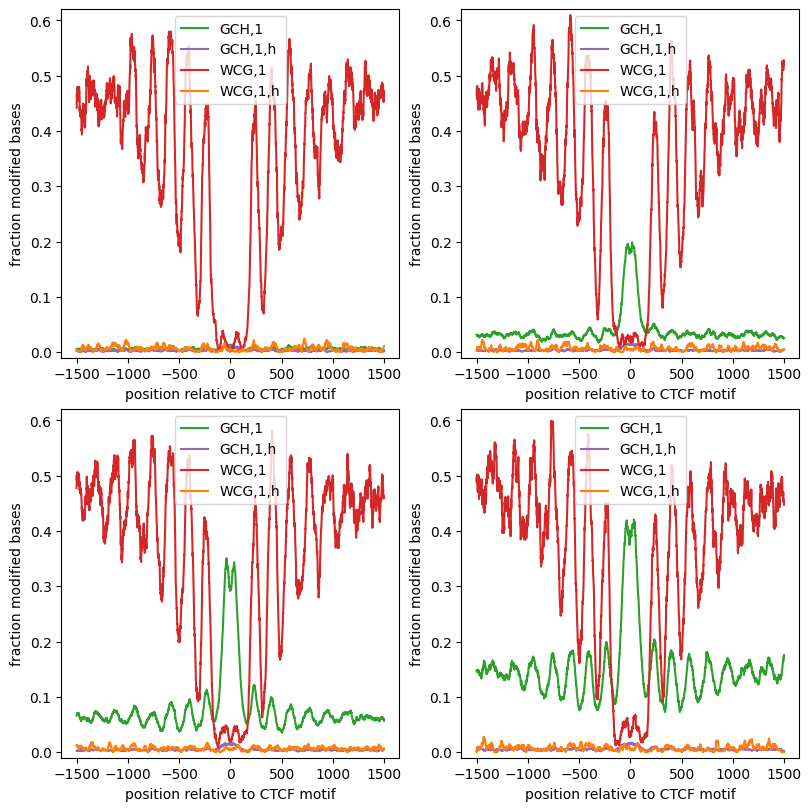

In [ ]:
_, axs = plt.subplots(2, 2, figsize=(8, 8), layout="constrained")
for barcode, ax in zip([13, 11, 10, 12], np.ravel(axs)):
    bam_file = bam_dir / f"barcode{barcode}.bam"
    # TODO: This should be renamed so that there is no risk of overlapping with demuxed files from another dataset; maybe make a subdirectory?
    output_id = f"{bam_file.stem}.{ctcf_bed_file.stem}"
    plot_enrichment_profile.by_modification(
        config.processed_data_dir / f"pileup.{output_id}.thresh75" / "pileup.sorted.bed.gz",
        regions=ctcf_bed_file,
        motifs= ["GCH,1", "GCH,1,h", "WCG,1", "WCG,1,h"],
        window_size=window_size,
        smooth_window=smoothing,
        palette=plotting.default_palette_map,
        ax=ax
    )
    ax.set_xlabel("position relative to CTCF motif")
    ax.set_ylim(y_lim)
    ax.legend(title="")

plt.savefig(config.figure_dir / "crosstalk.plot_enrichment_profile.5hmC.svg")
plt.show()
plt.close()